In [406]:
import sys, pandas as pd, numpy as np

## Dataset

In [407]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

## Preparing the dataset

In [408]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [409]:
features = ['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']

In [410]:
df= df[features]

## EDA

In [411]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

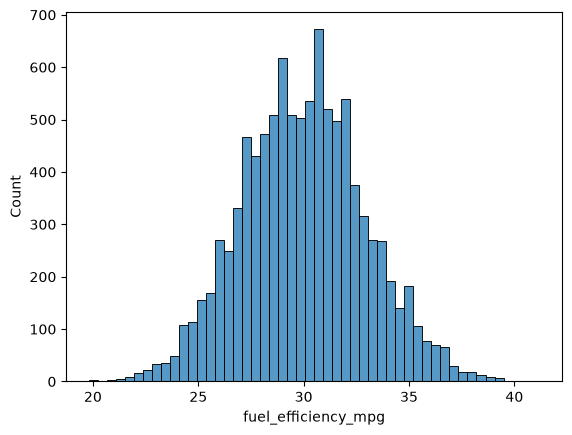

In [412]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

Look at the `fuel_efficiency_mpg` variable. Does it have a long tail? : No

## Question 1

There's one column with missing values. What is it?

- `'engine_displacement'`
- `'horsepower'`
- `'vehicle_weight'`
- `'model_year'`

---

In [413]:
missing = df.isnull().sum()
missing[missing > 0]

horsepower    877
dtype: int64

## Question 2

What's the median (50% percentile) for variable `'horsepower'`?

- 204
- 254
- 304
- 354

---

In [414]:
float(df['horsepower'].median())

254.0

## Prepare and split the dataset

In [415]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [416]:
n, n_train, n_val, n_test

(10000, 6000, 2000, 2000)

In [417]:
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

In [418]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [419]:
df_train.columns

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year',
       'fuel_efficiency_mpg'],
      dtype='str')

In [420]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [421]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [422]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [423]:
df_train.columns

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year'], dtype='str')

## Question 3
- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization
  using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using `round(score, 3)`. This
  keeps the imputation difference visible in this release.
- Which option gives better RMSE?

Options:

- With 0
- With mean
- Both are equally good

In [424]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

In [425]:
def prepare_X(df,fill):
    df_num = df[base]
    df_num = df_num.fillna(fill)
    X = df_num.values
    return X

In [426]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:] 

In [427]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [428]:
x_train0 = prepare_X(df_train,0)
w0, w= train_linear_regression(x_train0,y_train)

In [429]:
x_trainM = prepare_X(df_train,df_train['horsepower'].mean())
wM0, wM= train_linear_regression(x_trainM,y_train)

In [430]:
print("modèle 0 :", w0, w)
print("modèle M :", wM0, wM)

modèle 0 : -153.8849618823138 [-1.51505520e-03 -4.74024794e-06 -3.95418397e-03  1.02146785e-01]
modèle M : -153.29645639114293 [-0.00102386 -0.00648622 -0.00388828  0.10197897]


In [431]:
train_linear_regression(x_trainM,y_train)

(np.float64(-153.29645639114293),
 array([-0.00102386, -0.00648622, -0.00388828,  0.10197897]))

In [432]:
X_val0 = prepare_X(df_val,0)
y_pred0 = w0 + X_val0.dot(w)
rmse0=rmse(y_val, y_pred0)
round(rmse0,3)

np.float64(2.205)

In [433]:
X_valM = prepare_X(df_val,df_train['horsepower'].mean())
y_predM = wM0 + X_valM.dot(wM)
rmseM=rmse(y_val, y_predM)
round(rmseM,3)

np.float64(2.202)

Response : with mean (2.202 < 2.205)
Filling missing values of horsepower with mean improved the model quality as rmse decreased.

## Question 4

- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 4 decimal digits. This keeps the small but real
  regularization differences visible instead of turning several choices into a tie.
- Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.

Options:

- 0
- 0.01
- 0.1
- 1
- 5
- 10
- 100

---

In [434]:
def train_linear_regression_reg(X, y, r=r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [435]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    x_train = prepare_X(df_train,0)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    x_val = prepare_X(df_val,0)
    y_pred = w0 + x_val.dot(w)
    score = round((rmse(y_val, y_pred)),4)
    
    print(r, w0, score)

0 -153.8849618823138 2.2053
0.01 -148.3092124404723 2.2058
0.1 -111.83871039306318 2.2241
1 -32.331865964971264 2.3492
5 -7.7728522099734025 2.4094
10 -3.9871164160193766 2.4195
100 -0.40821964884790385 2.4292


Response: r=0 is the smallest that gives the best RMSE 2.2053 

# Question 5

- We used seed 42 for splitting the data. Let's find out how selecting the seed
  influences our score.
- Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation,
  use `np.std`.
- Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

- 0.006
- 0.016
- 0.029
- 0.036

> Note: Standard deviation shows how different the values are.
> If it's low, then all values are approximately the same.
> If it's high, the values are different.
> If standard deviation of scores is low, then our model is *stable*.

---

In [436]:
def prepare_idx(seed):
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)
    return idx

In [437]:
prepare_idx(2)

array([7878, 3224, 1919, ..., 6637, 2575, 7336], shape=(10000,))

In [438]:

scores = []

for seed in range(10):
    idx = prepare_idx(seed)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values

    x_train = prepare_X(df_train, 0)
    w0, w = train_linear_regression(x_train, y_train)

    x_val = prepare_X(df_val, 0)
    y_pred = w0 + x_val.dot(w)
    scores.append(float(rmse(y_val, y_pred)))     # brut
    print(seed, w0, round(scores[-1], 3))
    std_dev = np.std(scores)
    
print("\nscores :", scores)
std_dev = np.std(scores)
print("Standart Deviation    :", round(std_dev, 3))

0 -150.42885945053604 2.239
1 -151.61231559524532 2.202
2 -152.84068112584038 2.163
3 -152.33298096679098 2.204
4 -158.8885681645812 2.202
5 -151.8573533886124 2.246
6 -154.3717913727048 2.27
7 -155.01835258995723 2.191
8 -150.4381740048234 2.217
9 -154.3600748895819 2.207

scores : [2.239204143046126, 2.2021128210838845, 2.1634197787530947, 2.2043588768539224, 2.2018800943311554, 2.2457851509085134, 2.2697212079524043, 2.190794599933443, 2.216611201686444, 2.2070365928178957]
Standart Deviation    : 0.029


The standart deviation is 0.029

## Question 6

- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with `r=0.001`.
- What's the RMSE on the test dataset?

Options:

- 0.236
- 2.236
- 22.10
- 221.0

In [442]:
idx = prepare_idx(9)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values

x_train = prepare_X(df_train, 0)
w0, w = train_linear_regression_reg(x_train, y_train, r=0.001)

x_val = prepare_X(df_val, 0)
y_pred = w0 + x_val.dot(w)
score = float(rmse(y_val, y_pred))
print(w0, round(score, 3))


-153.7818997788496 2.207


In [459]:
df_full_train = pd.concat([df_train, df_val])

In [461]:
df_full_train = df_full_train.reset_index(drop=True)

In [462]:
df_full_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2320,246.0,4100,2014,32.5
1,2230,252.0,4250,1998,33.2
2,2700,276.0,4490,2008,32.4
3,2220,269.0,4060,2004,29.9
4,2370,NaN,4690,1979,26.4
...,...,...,...,...,...
7995,2690,324.0,4510,2023,35.7
7996,1920,190.0,4000,1998,30.8
7997,1800,225.0,3980,1994,29.1
7998,1970,232.0,3560,2009,32.2


In [447]:
X_full_train = prepare_X(df_full_train,0)

In [448]:
y_full_train = np.concatenate([y_train, y_val])

In [455]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
w0, w

(np.float64(-152.37535772493302),
 array([-0.00135534, -0.00042645, -0.00401765,  0.10140402]))

In [471]:
x_test = prepare_X(df_test, 0)
y_pred = w0 + x_test.dot(w)
y_test = df_test.fuel_efficiency_mpg.values
score = round(float(rmse(y_test, y_pred)),3)
score


2.236

RMSE du test est 2.236